<a href="https://colab.research.google.com/github/PradenaTiara/Machine-Learning/blob/main/672022028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title classifikasi-KNN

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import matplotlib.ticker as ticker

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [ ]:
!wget -O teleCust1000t.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/teleCust1000t.csv

--2024-05-10 19:34:04--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/teleCust1000t.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37048 (36K) [text/csv]
Saving to: ‘teleCust1000t.csv’

teleCust1000t.csv   100%[===================>]  36.18K  --.-KB/s    in 0.03s   

2024-05-10 19:34:04 (1.37 MB/s) - ‘teleCust1000t.csv’ saved [37048/37048]



In [ ]:
df = pd.read_csv('teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [ ]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

array([[<Axes: title={'center': 'age'}>]], dtype=object)

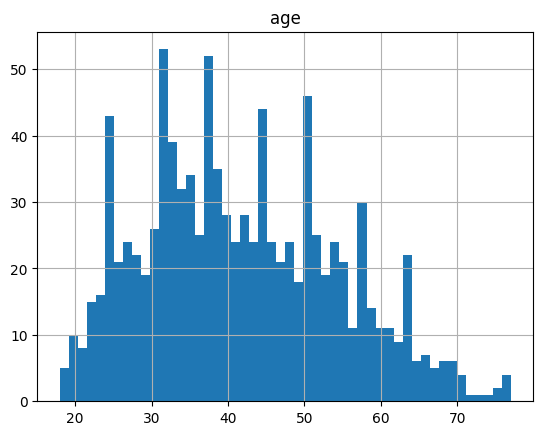

In [ ]:
df.hist(column ='age',bins = 50)

In [ ]:
df.columns

Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='object')

In [ ]:
x =df[['age']].values
x[0:5]

array([[44],
       [33],
       [52],
       [33],
       [30]])

In [ ]:
y = df ['income'].values
y[0:5]

array([ 64., 136., 116.,  33.,  30.])

In [ ]:
x = preprocessing.StandardScaler().fit(x).transform(x.astype(float))
x[0:5]

array([[ 0.18450456],
       [-0.69181243],
       [ 0.82182601],
       [-0.69181243],
       [-0.93080797]])

In [ ]:
# @title kalau data sudah rapi dan siap, baru kita lakukan SPLIT DATA


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x,y, test_size =0.2, random_state=4)
print('Data Training sebanyak = ', x_train.shape, y_train.shape)
print('Data Testing sebanyak = ', x_test.shape, y_test.shape)

Data Training sebanyak =  (800, 1) (800,)
Data Testing sebanyak =  (200, 1) (200,)


In [ ]:
# @title buat model


In [ ]:
# @title Fase Training


In [ ]:
k = 21
neigh = KNeighborsClassifier(n_neighbors = k).fit(x_train, y_train)
neigh

KNeighborsClassifier(n_neighbors=21)

In [ ]:
# @title Fase testing


In [ ]:
yhat = neigh.predict(x_test)
yhat[0:50]

array([25., 19., 12., 21., 33., 66., 21., 22., 46., 64., 24., 21., 64.,
       25.,  9., 27., 19., 41.,  9., 25., 11., 37., 25., 34., 28., 50.,
       24., 28., 56., 25., 37., 19., 34., 46., 25., 46., 12., 34., 46.,
       22., 12., 39., 21., 28., 28., 28.,  9., 39., 12., 53.])

In [ ]:
# @title Cek Akurasi

In [ ]:
print("Akurasi set Train: ", metrics.accuracy_score(y_train, neigh.predict(x_train)))
print("Akurasi set Test: ", metrics.accuracy_score(y_test, yhat))

Akurasi set Train:  0.1
Akurasi set Test:  0.015


In [ ]:
# @title Hitung K mana yg paling pas


In [ ]:
ks = 100
mean_acc = np.zeros((ks-1))
std_acc = np.zeros((ks-1))
ConfusionMx = [];
for n in range (1,ks):

  #train model baru ke prediksi
  neigh = KNeighborsClassifier(n_neighbors=n).fit(x_train, y_train)
  yhat = neigh.predict(x_test)

  mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)
  std_acc[n-1] = np.std(yhat == y_test)/np.sqrt(yhat.shape[0]) #menghitung standart defisiasi

mean_acc

array([0.005, 0.005, 0.02 , 0.015, 0.01 , 0.01 , 0.015, 0.015, 0.02 ,
       0.025, 0.02 , 0.015, 0.015, 0.015, 0.015, 0.015, 0.025, 0.02 ,
       0.015, 0.01 , 0.015, 0.015, 0.015, 0.02 , 0.02 , 0.025, 0.025,
       0.025, 0.03 , 0.025, 0.03 , 0.03 , 0.03 , 0.03 , 0.025, 0.03 ,
       0.025, 0.02 , 0.03 , 0.03 , 0.025, 0.015, 0.02 , 0.02 , 0.02 ,
       0.025, 0.03 , 0.035, 0.035, 0.03 , 0.035, 0.035, 0.035, 0.035,
       0.035, 0.035, 0.035, 0.03 , 0.03 , 0.03 , 0.03 , 0.025, 0.02 ,
       0.02 , 0.015, 0.015, 0.015, 0.015, 0.015, 0.015, 0.015, 0.015,
       0.015, 0.015, 0.015, 0.015, 0.02 , 0.02 , 0.02 , 0.02 , 0.02 ,
       0.02 , 0.02 , 0.015, 0.015, 0.01 , 0.01 , 0.01 , 0.01 , 0.01 ,
       0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.01 , 0.015])

<ipython-input-22-3a146d0140fa>:3: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('Accuracy','+/-3xstd')


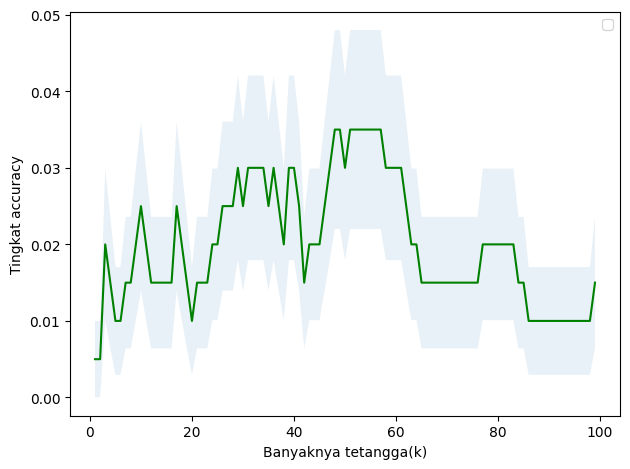

In [ ]:
plt.plot (range(1,ks), mean_acc, 'g')
plt.fill_between(range(1,ks), mean_acc - 1* std_acc, mean_acc + 1* std_acc, alpha = 0.10)
plt.legend('Accuracy','+/-3xstd')
plt.ylabel('Tingkat accuracy')
plt.xlabel('Banyaknya tetangga(k)')
plt.tight_layout()


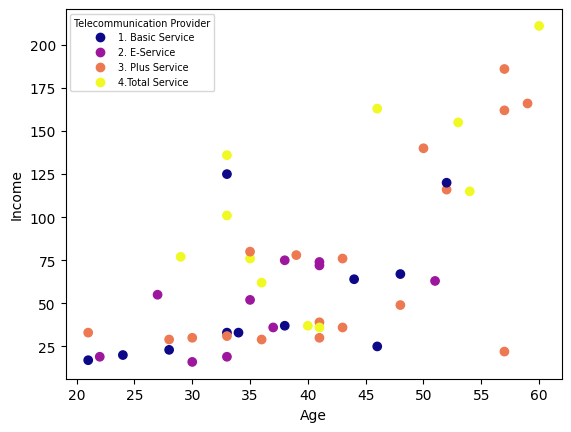

In [ ]:
cc = df['custcat'].values
inc = df['income'].values
a = df['age'].values

scatter = plt.scatter(a[:50], inc[:50], c=cc[:50], cmap='plasma')
cb = scatter
plt.xlabel('Age')
plt.ylabel('Income')

plt.legend(handles=scatter.legend_elements()[0], title='Telecommunication Provider',title_fontsize='x-small', fontsize='x-small', labels=['1. Basic Service', '2. E-Service', '3. Plus Service', '4.Total Service'], loc='upper left')

plt.show()